In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_excel("EastWestAirlines.xlsx")
df.head()

,East-West Airlines is trying to learn more about its customers. Key issues are their,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,"flying patterns, earning and use of frequent f...",NaN,NaN,NaN,NaN
1,card. The task is to identify customer segmen...,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN
4,Source: Based upon real business data; company...,NaN,NaN,NaN,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 5 columns):
 #   Column                                                                                 Non-Null Count  Dtype 
---  ------                                                                                 --------------  ----- 
 0   East-West Airlines is trying to learn more about its customers.  Key issues are their  18 non-null     object
 1   Unnamed: 1                                                                             13 non-null     object
 2   Unnamed: 2                                                                             6 non-null      object
 3   Unnamed: 3                                                                             13 non-null     object
 4   Unnamed: 4                                                                             18 non-null     object
dtypes: object(5)
memory usage: 1.1+ KB


In [4]:
df.describe()

,East-West Airlines is trying to learn more about its customers. Key issues are their,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4
count,18,13,6,13,18
unique,18,3,3,3,18
top,"flying patterns, earning and use of frequent f...",NUMBER,1,Raw,Description
freq,1,9,3,9,1


In [5]:
df.drop(columns=['ID#'], inplace=True, errors='ignore')

In [6]:
df = df.apply(pd.to_numeric, errors='coerce')

In [7]:
print("Before Cleaning:\n", df.isnull().sum())

Before Cleaning:
 East-West Airlines is trying to learn more about its customers.  Key issues are their    26
Unnamed: 1                                                                               26
Unnamed: 2                                                                               21
Unnamed: 3                                                                               26
Unnamed: 4                                                                               26
dtype: int64


In [8]:
# Fill with mean
df = df.fillna(df.mean(numeric_only=True))

# Final fallback → fill remaining with 0
df = df.fillna(0)

In [9]:
print("Remaining NaN:", df.isnull().sum().sum())

Remaining NaN: 0


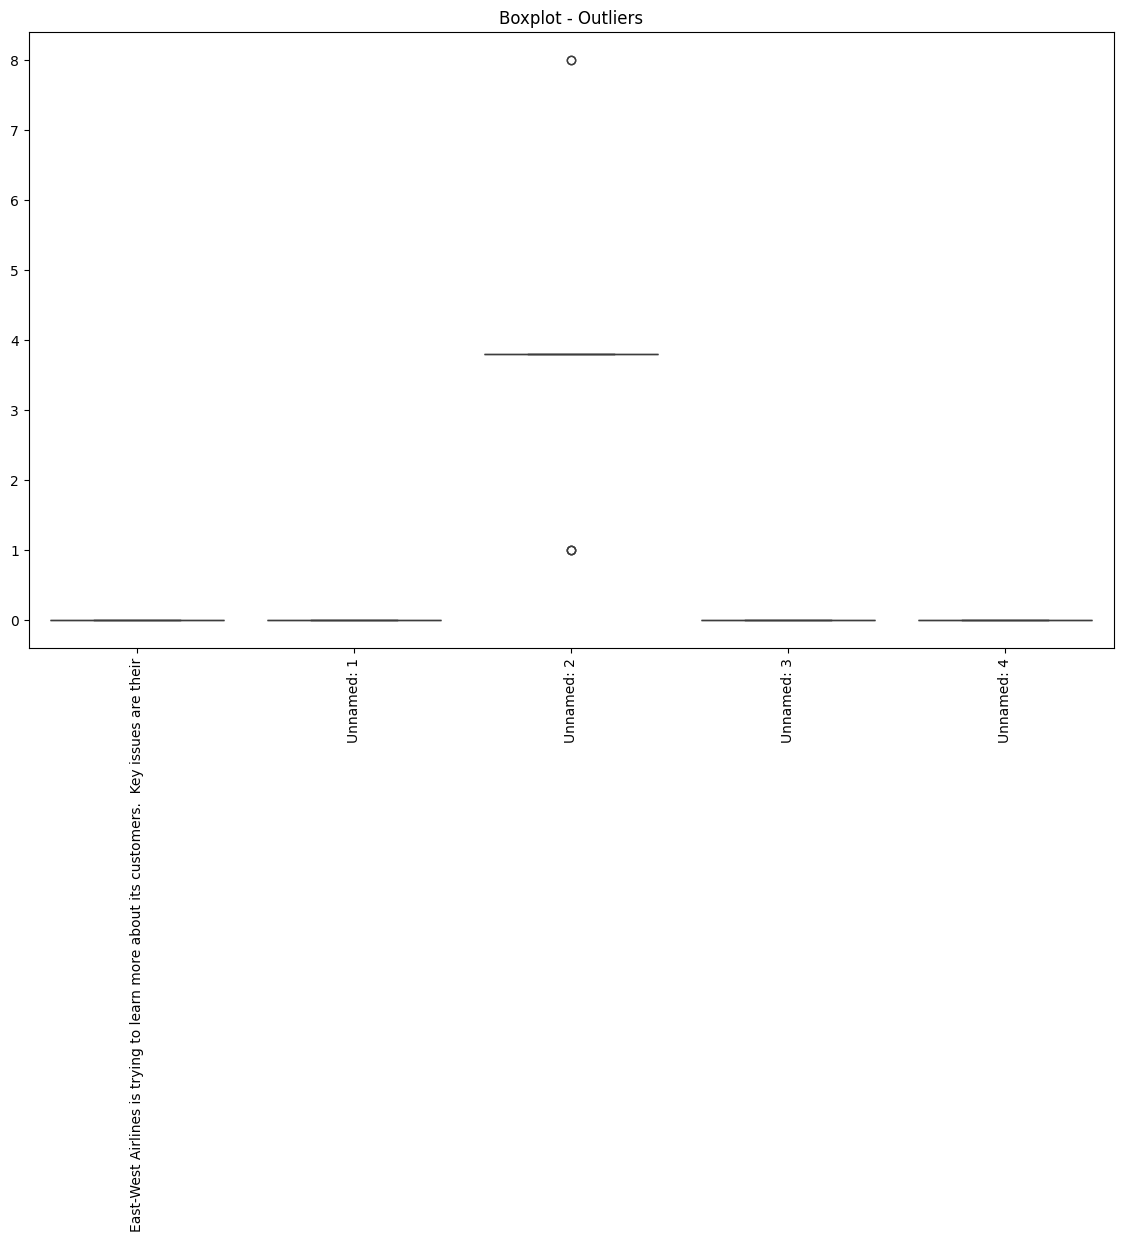

In [10]:
#outlier ditection
plt.figure(figsize=(14,8))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title("Boxplot - Outliers")
plt.show()

In [11]:
def cap_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower_bound, lower_bound,
                       np.where(df[col] > upper_bound, upper_bound, df[col]))

# Apply capping to all numeric columns
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    cap_outliers(df, col)

print("Outliers capped successfully!")

Outliers capped successfully!


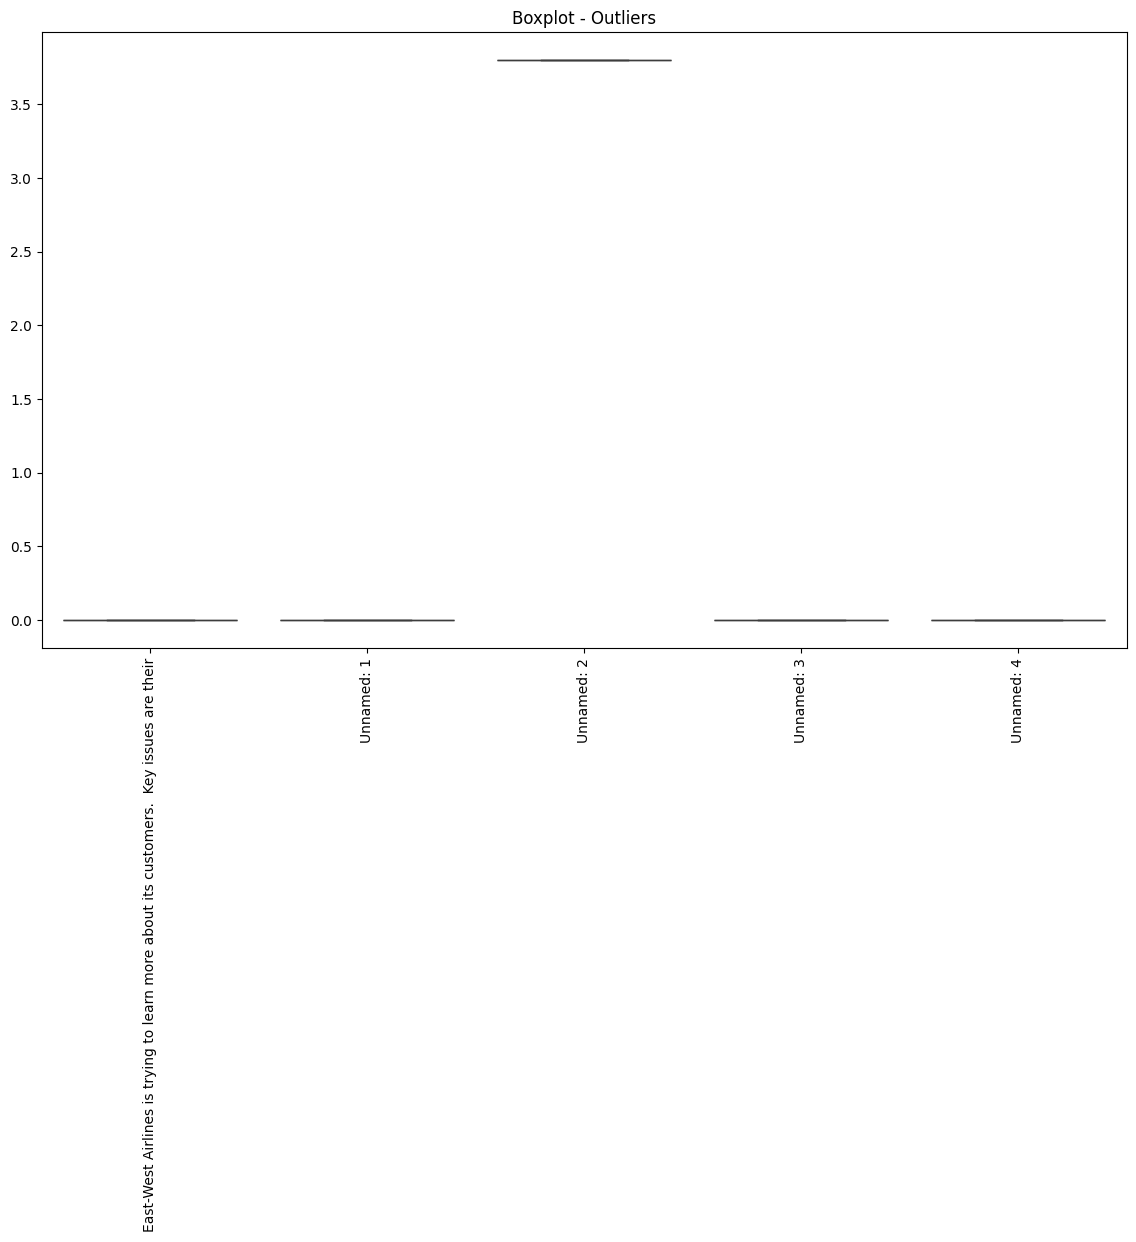

In [12]:
plt.figure(figsize=(14,8))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title("Boxplot - Outliers")
plt.show()

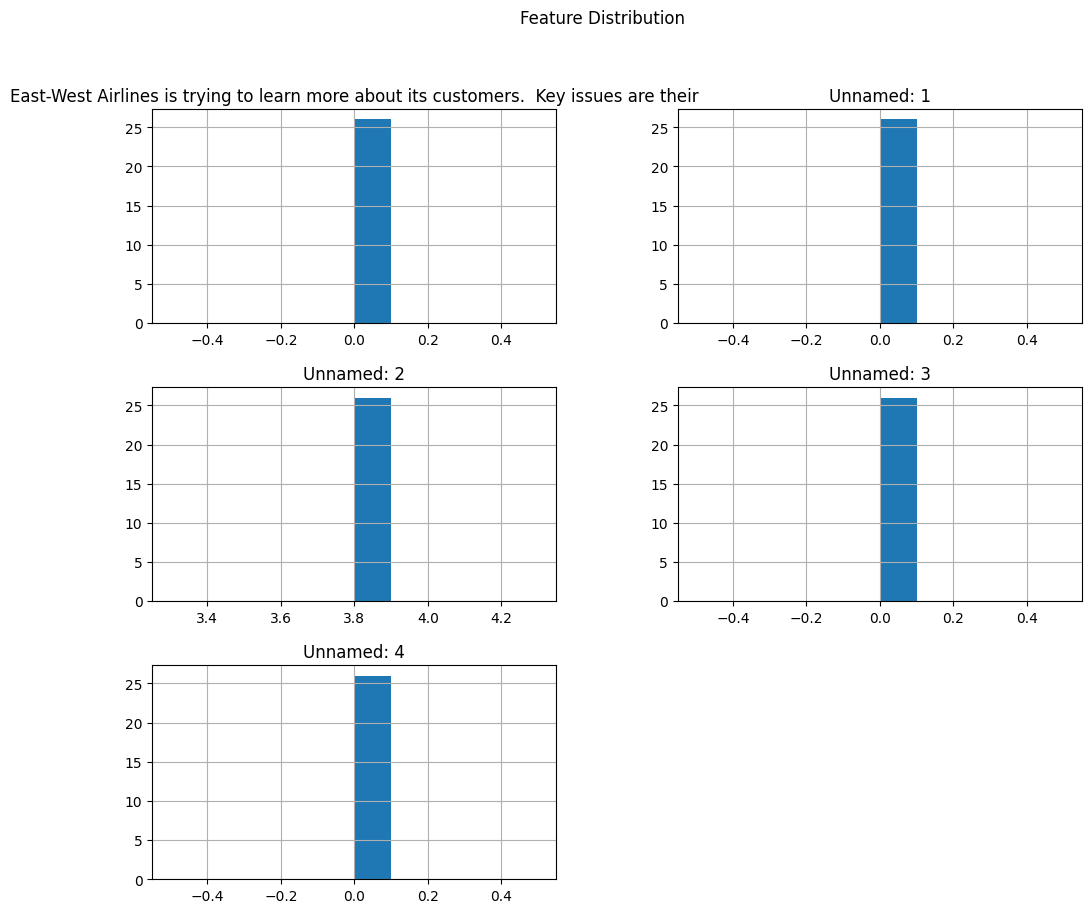

In [13]:
#Heatmap Distribution
df.hist(figsize=(12,10))
plt.suptitle("Feature Distribution")
plt.show()

In [14]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# Safety (No NaN / Inf)
scaled_data = np.nan_to_num(scaled_data)

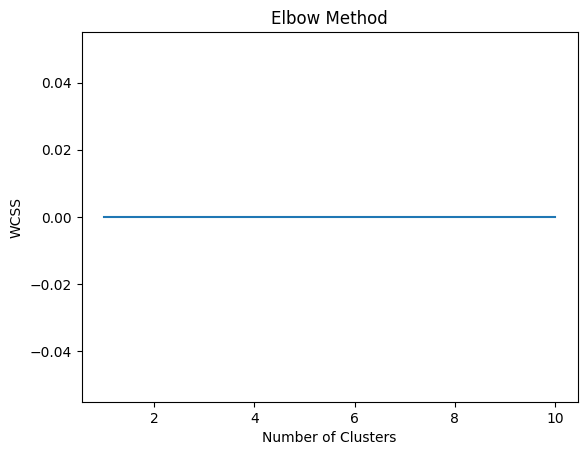

In [15]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [16]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(scaled_data)

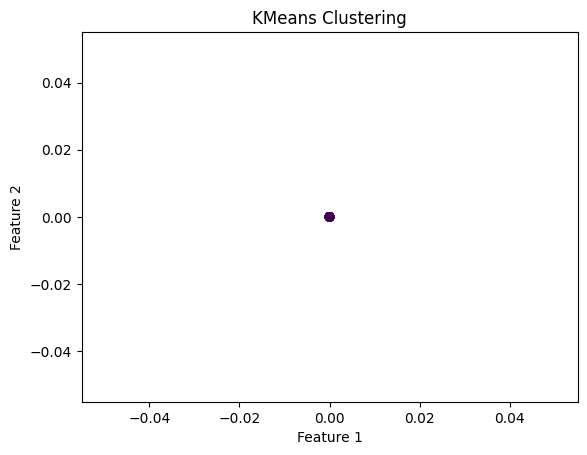

In [17]:
plt.scatter(scaled_data[:,0], scaled_data[:,1], c=kmeans_labels)

plt.title("KMeans Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [18]:
print("Silhouette Score (KMeans):", silhouette_score(scaled_data, kmeans_labels))

ValueError: Number of labels is 1. Valid values are 2 to n_samples - 1 (inclusive)

In [ ]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(scaled_data)

In [ ]:
plt.scatter(scaled_data[:,0], scaled_data[:,1], c=dbscan_labels)

plt.title("DBSCAN Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [ ]:
labels = set(dbscan_labels)

if len(labels) > 1 and -1 not in labels:
    print("Silhouette Score (DBSCAN):", silhouette_score(scaled_data, dbscan_labels))
else:
    print("DBSCAN me noise ya single cluster hai (normal case)")

In [ ]:
df['Cluster'] = kmeans_labels

print(df.groupby('Cluster').mean())